# Function to bin data and plot heatmap

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.basemap import Basemap

In [3]:
# Get data into dataframe
df = pd.read_csv('../../../WMA_fractions_v2.csv', skiprows=1)

# Preprocess data to only have temperature, salinity and dissolved oxygen
df_ST = df.copy()
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','Datetime_[UTC]']]
df_ST['year'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.year
df_ST['month'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.month
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','year', 'month']]

In [9]:
def plot_heatmap_npts_xy(ds_cleaned, n_x_bins=100, n_y_bins=100, bin_max=None, projection='npstere', projection_name='Polar Stereographic'):
    lat_min = ds_cleaned['Latitude_[deg_N]'].min()
    resolution = 'l'

    fig = plt.figure(figsize=(8, 8), dpi=300)
    m = Basemap(projection=projection, boundinglat=lat_min, lon_0=0, resolution=resolution)

    # Convert lat/lon → x/y (projection coordinates in meters)
    lon_vals = ds_cleaned['Longitude_[deg_E]'].values
    lat_vals = ds_cleaned['Latitude_[deg_N]'].values

    # Reproject lat/lon to x/y
    x_vals, y_vals = m(lon_vals, lat_vals)

    # Define XY bin edges
    x_min, x_max = x_vals.min(), x_vals.max()
    y_min, y_max = y_vals.min(), y_vals.max()

    x_bins = np.linspace(x_min, x_max, n_x_bins + 1)
    y_bins = np.linspace(y_min, y_max, n_y_bins + 1)

    # Grid to store max depth
    H = np.zeros((n_x_bins, n_y_bins))

    # Digitize into bins
    x_idx = np.digitize(x_vals, x_bins) - 1
    y_idx = np.digitize(y_vals, y_bins) - 1

    # Count number of points in each bin
    for i in range(len(x_vals)):
        xi, yi = x_idx[i], y_idx[i]
        if 0 <= xi < n_x_bins and 0 <= yi < n_y_bins:
            H[xi, yi] += 1

    # Create meshgrid for plotting
    X, Y = np.meshgrid(x_bins, y_bins)

    # Colormap
    cmap = plt.get_cmap('Wistia').copy()
    cmap.set_under(color='white', alpha=1.0)
    cmap.set_over(color='white', alpha=1.0)

    if bin_max is None:
        bin_max = H.max()

    # Plot heatmap
    m.pcolormesh(X, Y, H.T, cmap=cmap, vmin=1, vmax=bin_max)

    # Draw bin grid (in xy space)
    for xb in x_bins:
        plt.plot([xb]*len(y_bins), y_bins, color='grey', linewidth=0.05, zorder=3)
    for yb in y_bins:
        plt.plot(x_bins, [yb]*len(x_bins), color='grey', linewidth=0.05, zorder=3)

    # Plot coastlines on top
    m.drawcoastlines()
    m.fillcontinents(color='lightgrey', lake_color='lightblue')

    cbar = m.colorbar(location='bottom', pad="5%")
    cbar.set_label('Number of points per bin')

    plt.xticks([])
    plt.yticks([])
    plt.title('Number of Points per Bin in '+ f'{projection_name} ')

    plt.show()

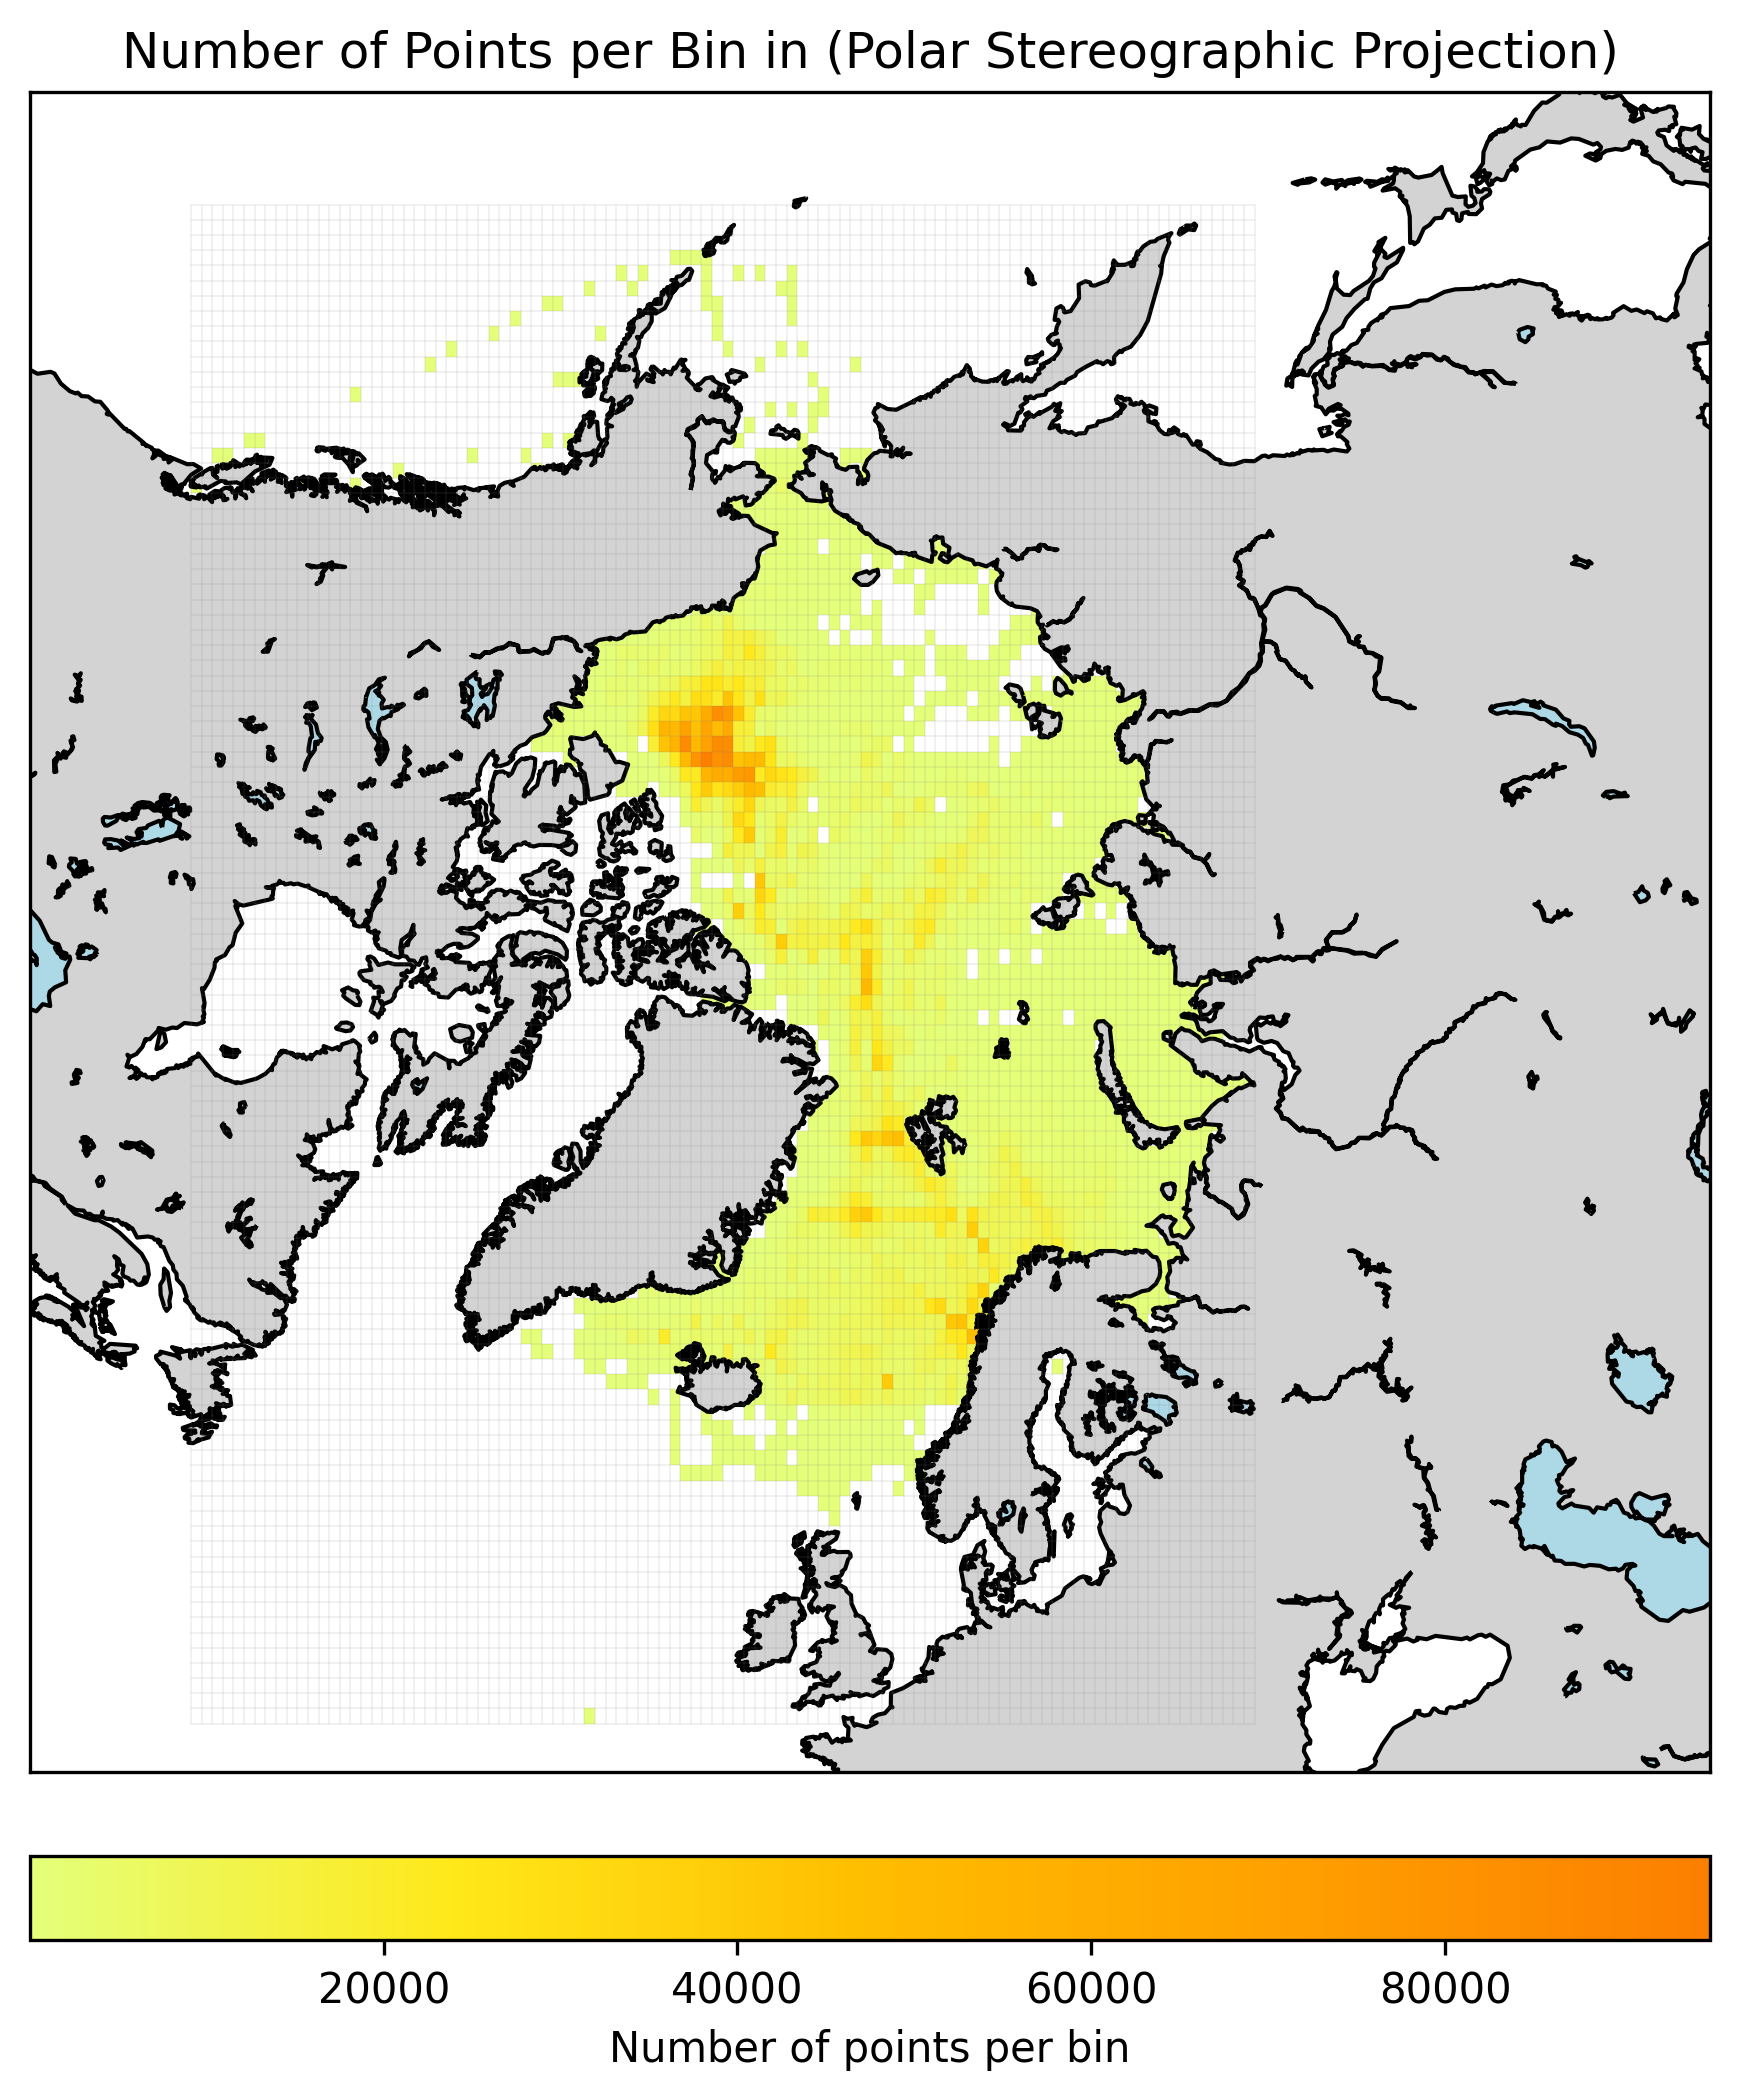

In [4]:
plot_heatmap_npts_xy(df_ST, n_x_bins=100, n_y_bins=100, projection='npstere', projection_name='Polar Stereographic Projection')

# Can also plot in other projections e.g. Polar Lambert Azimuthal Projection

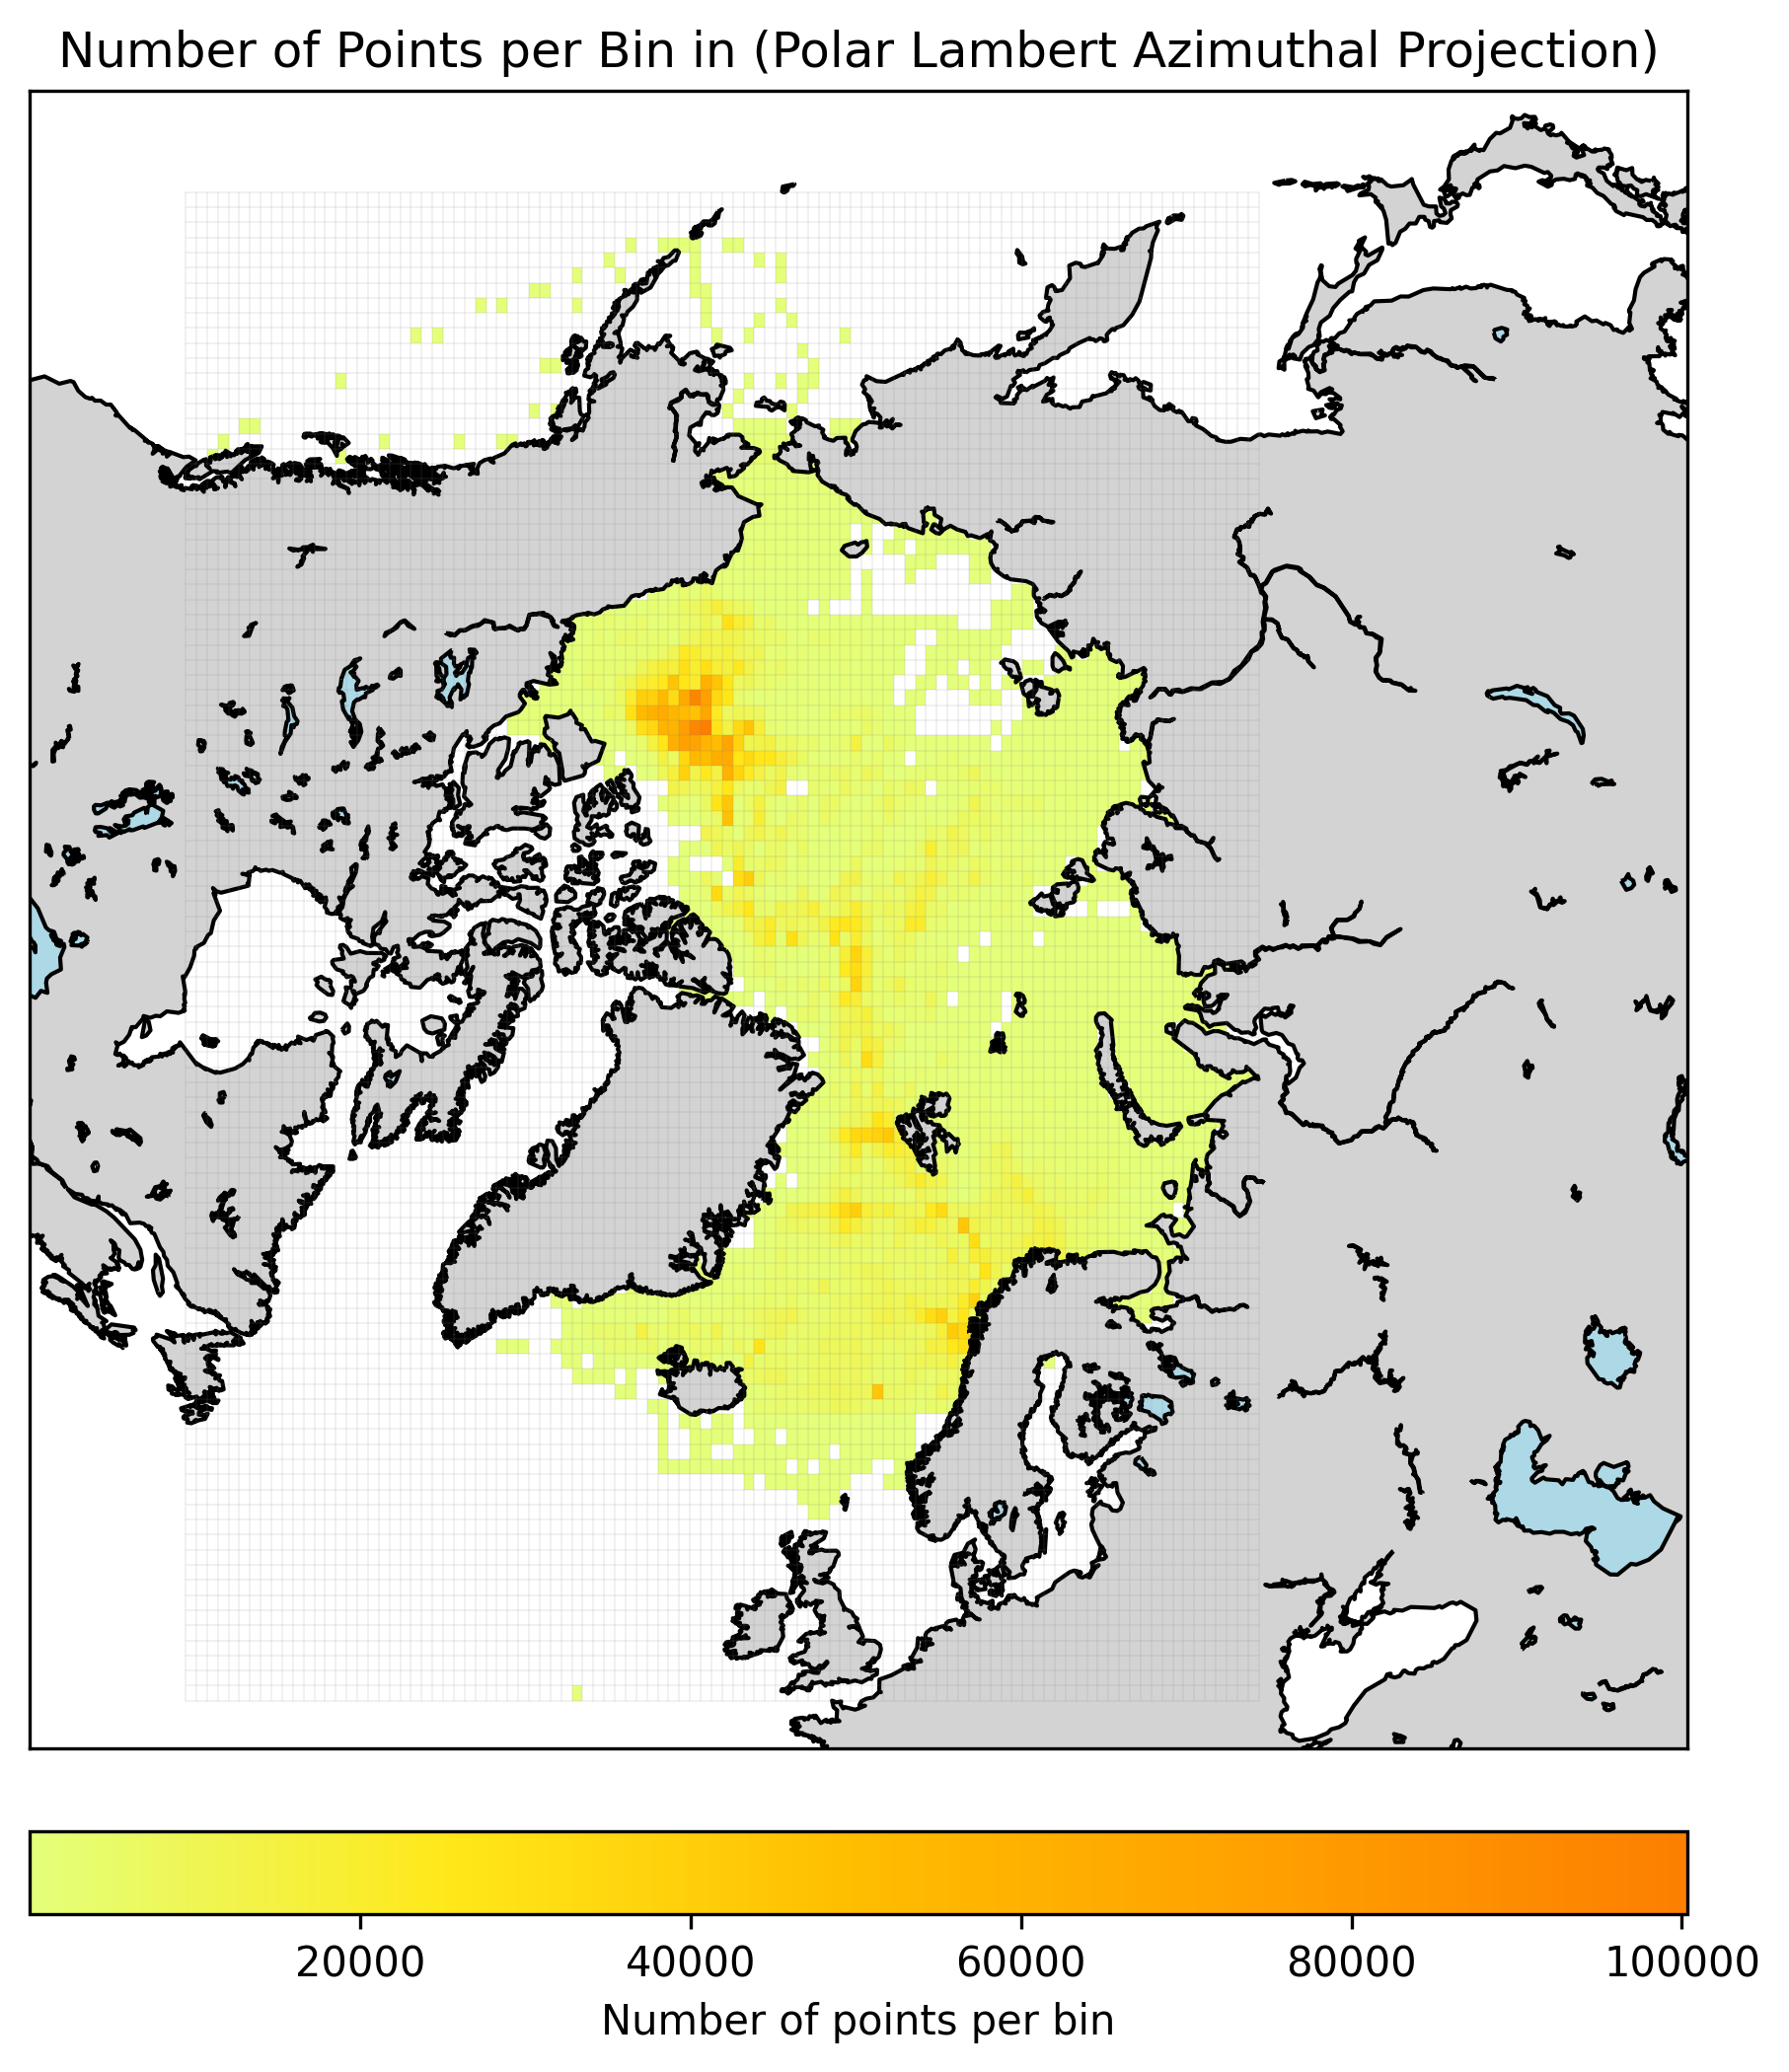

In [5]:
plot_heatmap_npts_xy(df_ST, n_x_bins=100, n_y_bins=100, projection='nplaea', projection_name='Polar Lambert Azimuthal Projection')

In [5]:
df_ST_80_90 = df_ST[(df_ST['year'] >= 1980) & (df_ST['year'] <= 1990)]
df_ST_90_00 = df_ST[(df_ST['year'] >= 1990) & (df_ST['year'] <= 2000)]
df_ST_00_10 = df_ST[(df_ST['year'] >= 2000) & (df_ST['year'] <= 2010)]
df_ST_10_23 = df_ST[(df_ST['year'] >= 2010) & (df_ST['year'] <= 2023)]

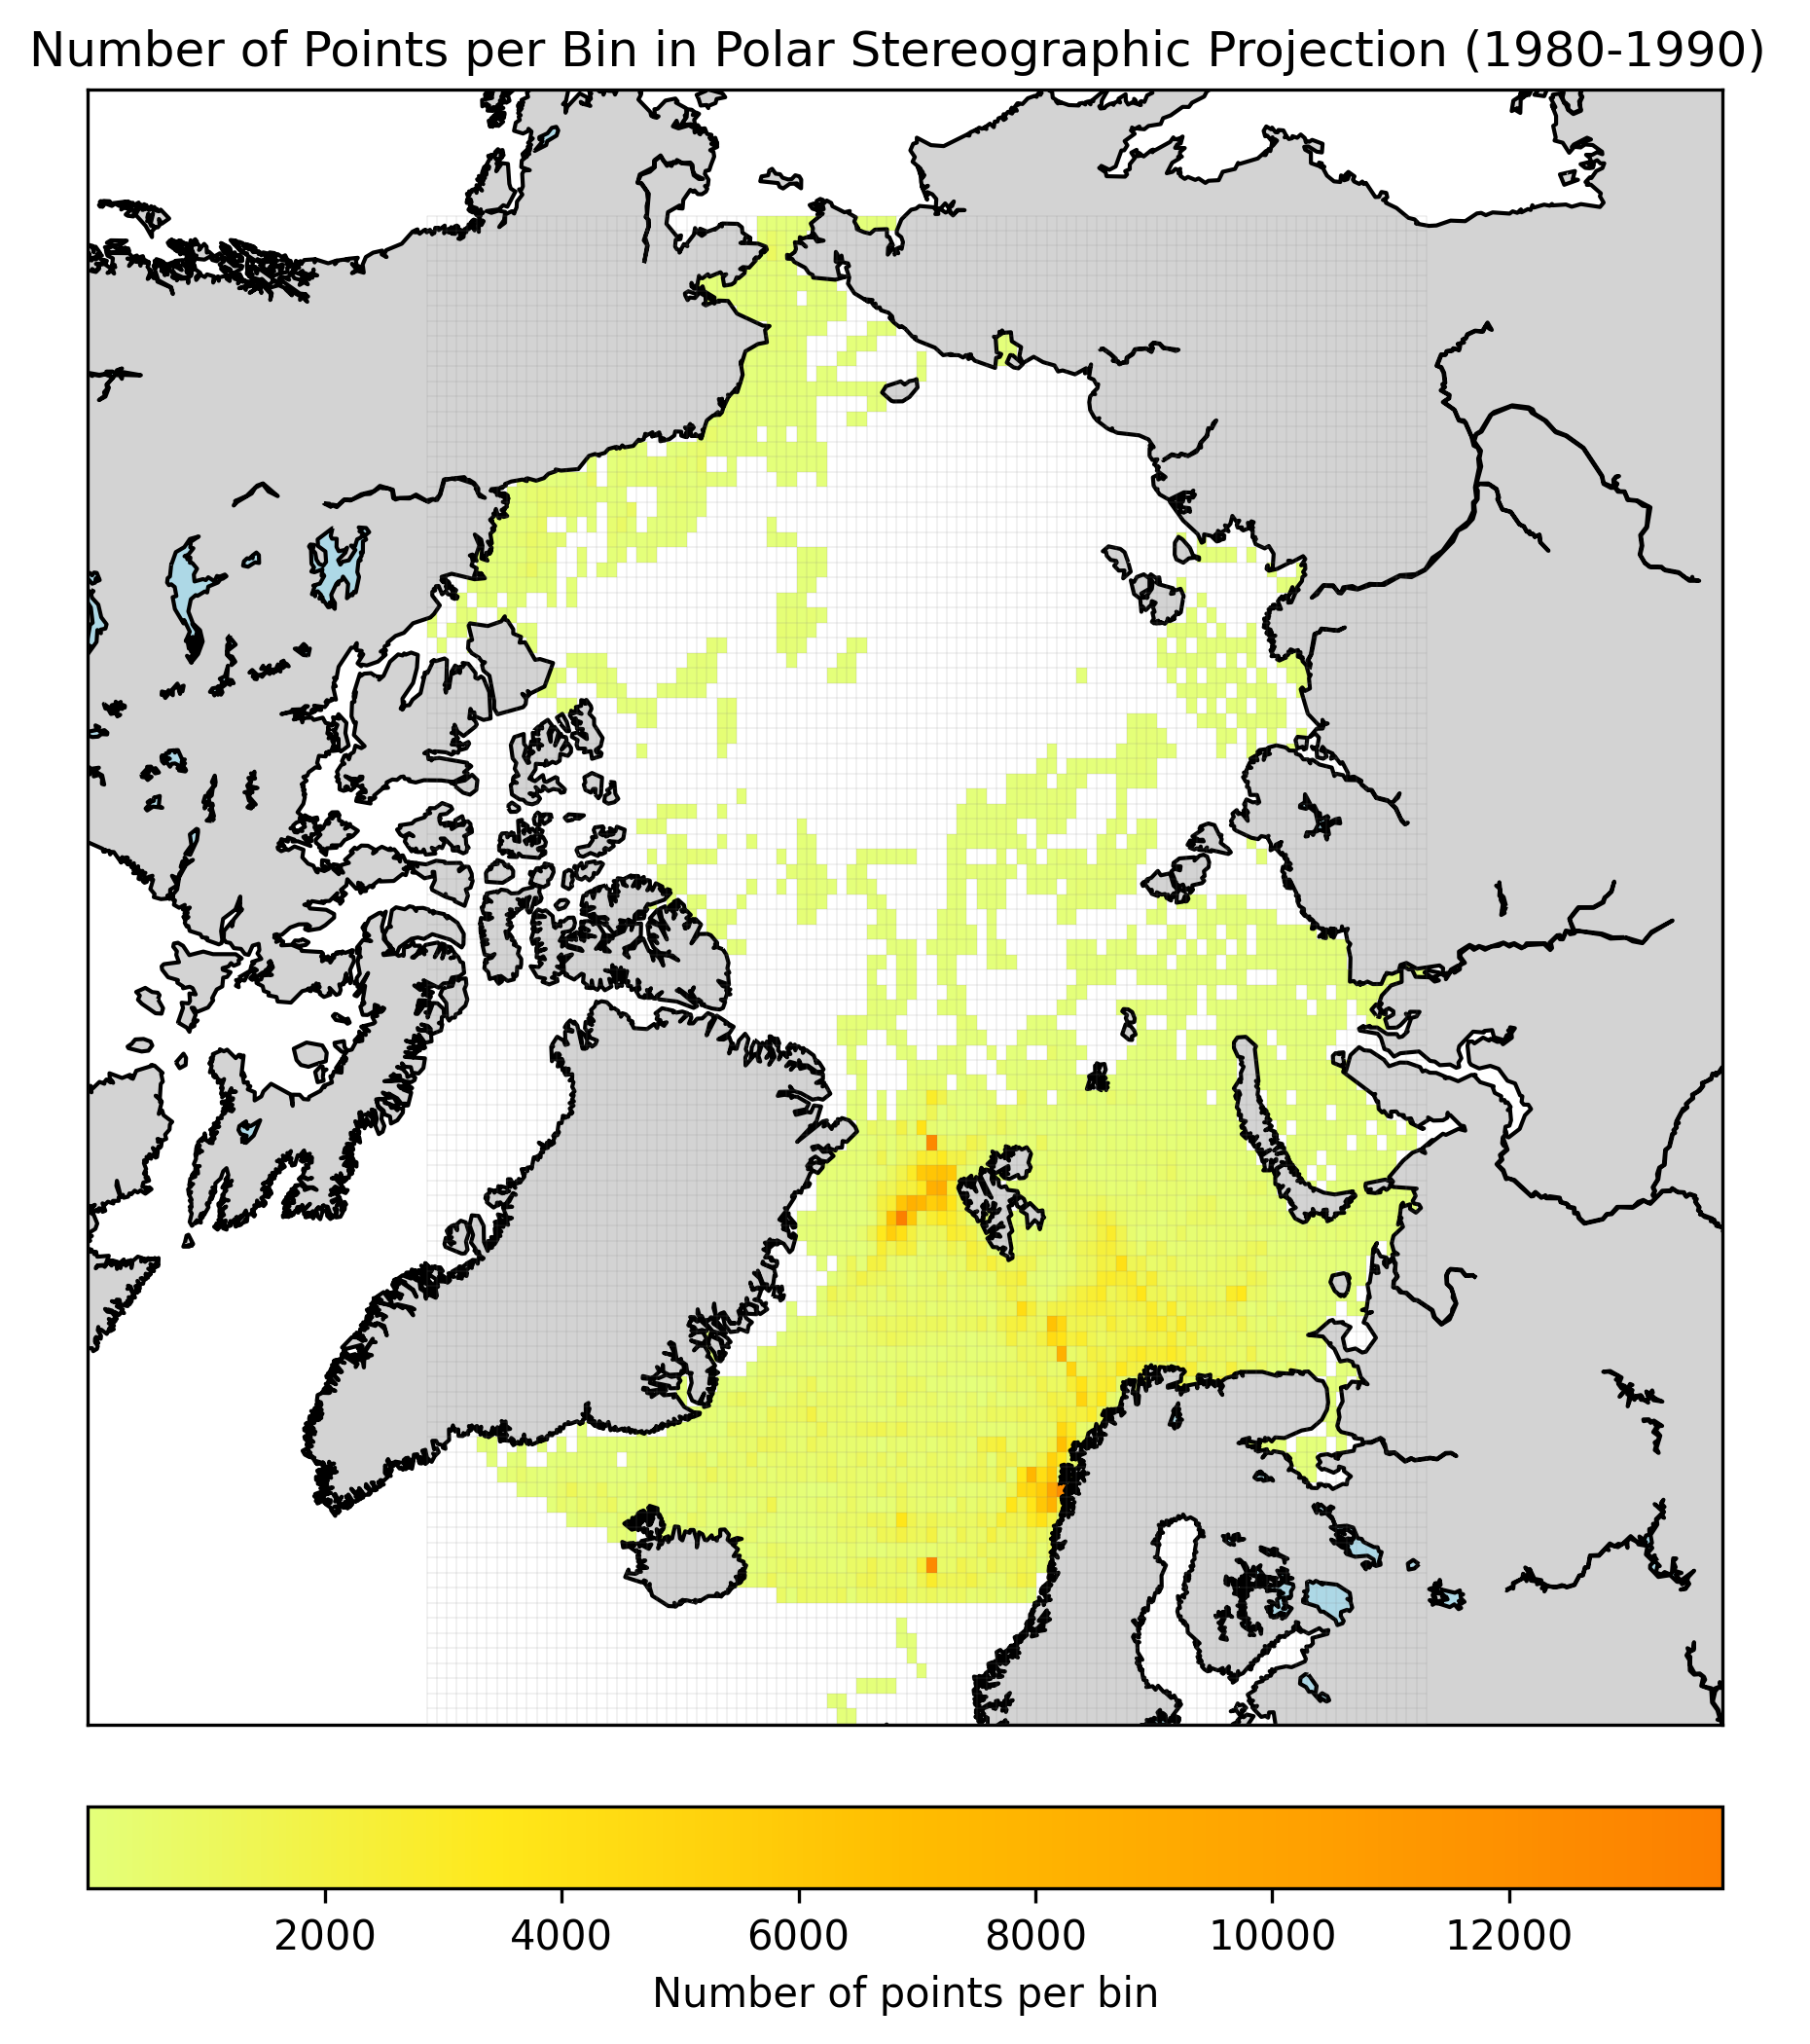

In [10]:
plot_heatmap_npts_xy(df_ST_80_90, n_x_bins=100, n_y_bins=100, projection='npstere', projection_name='Polar Stereographic Projection (1980-1990)')

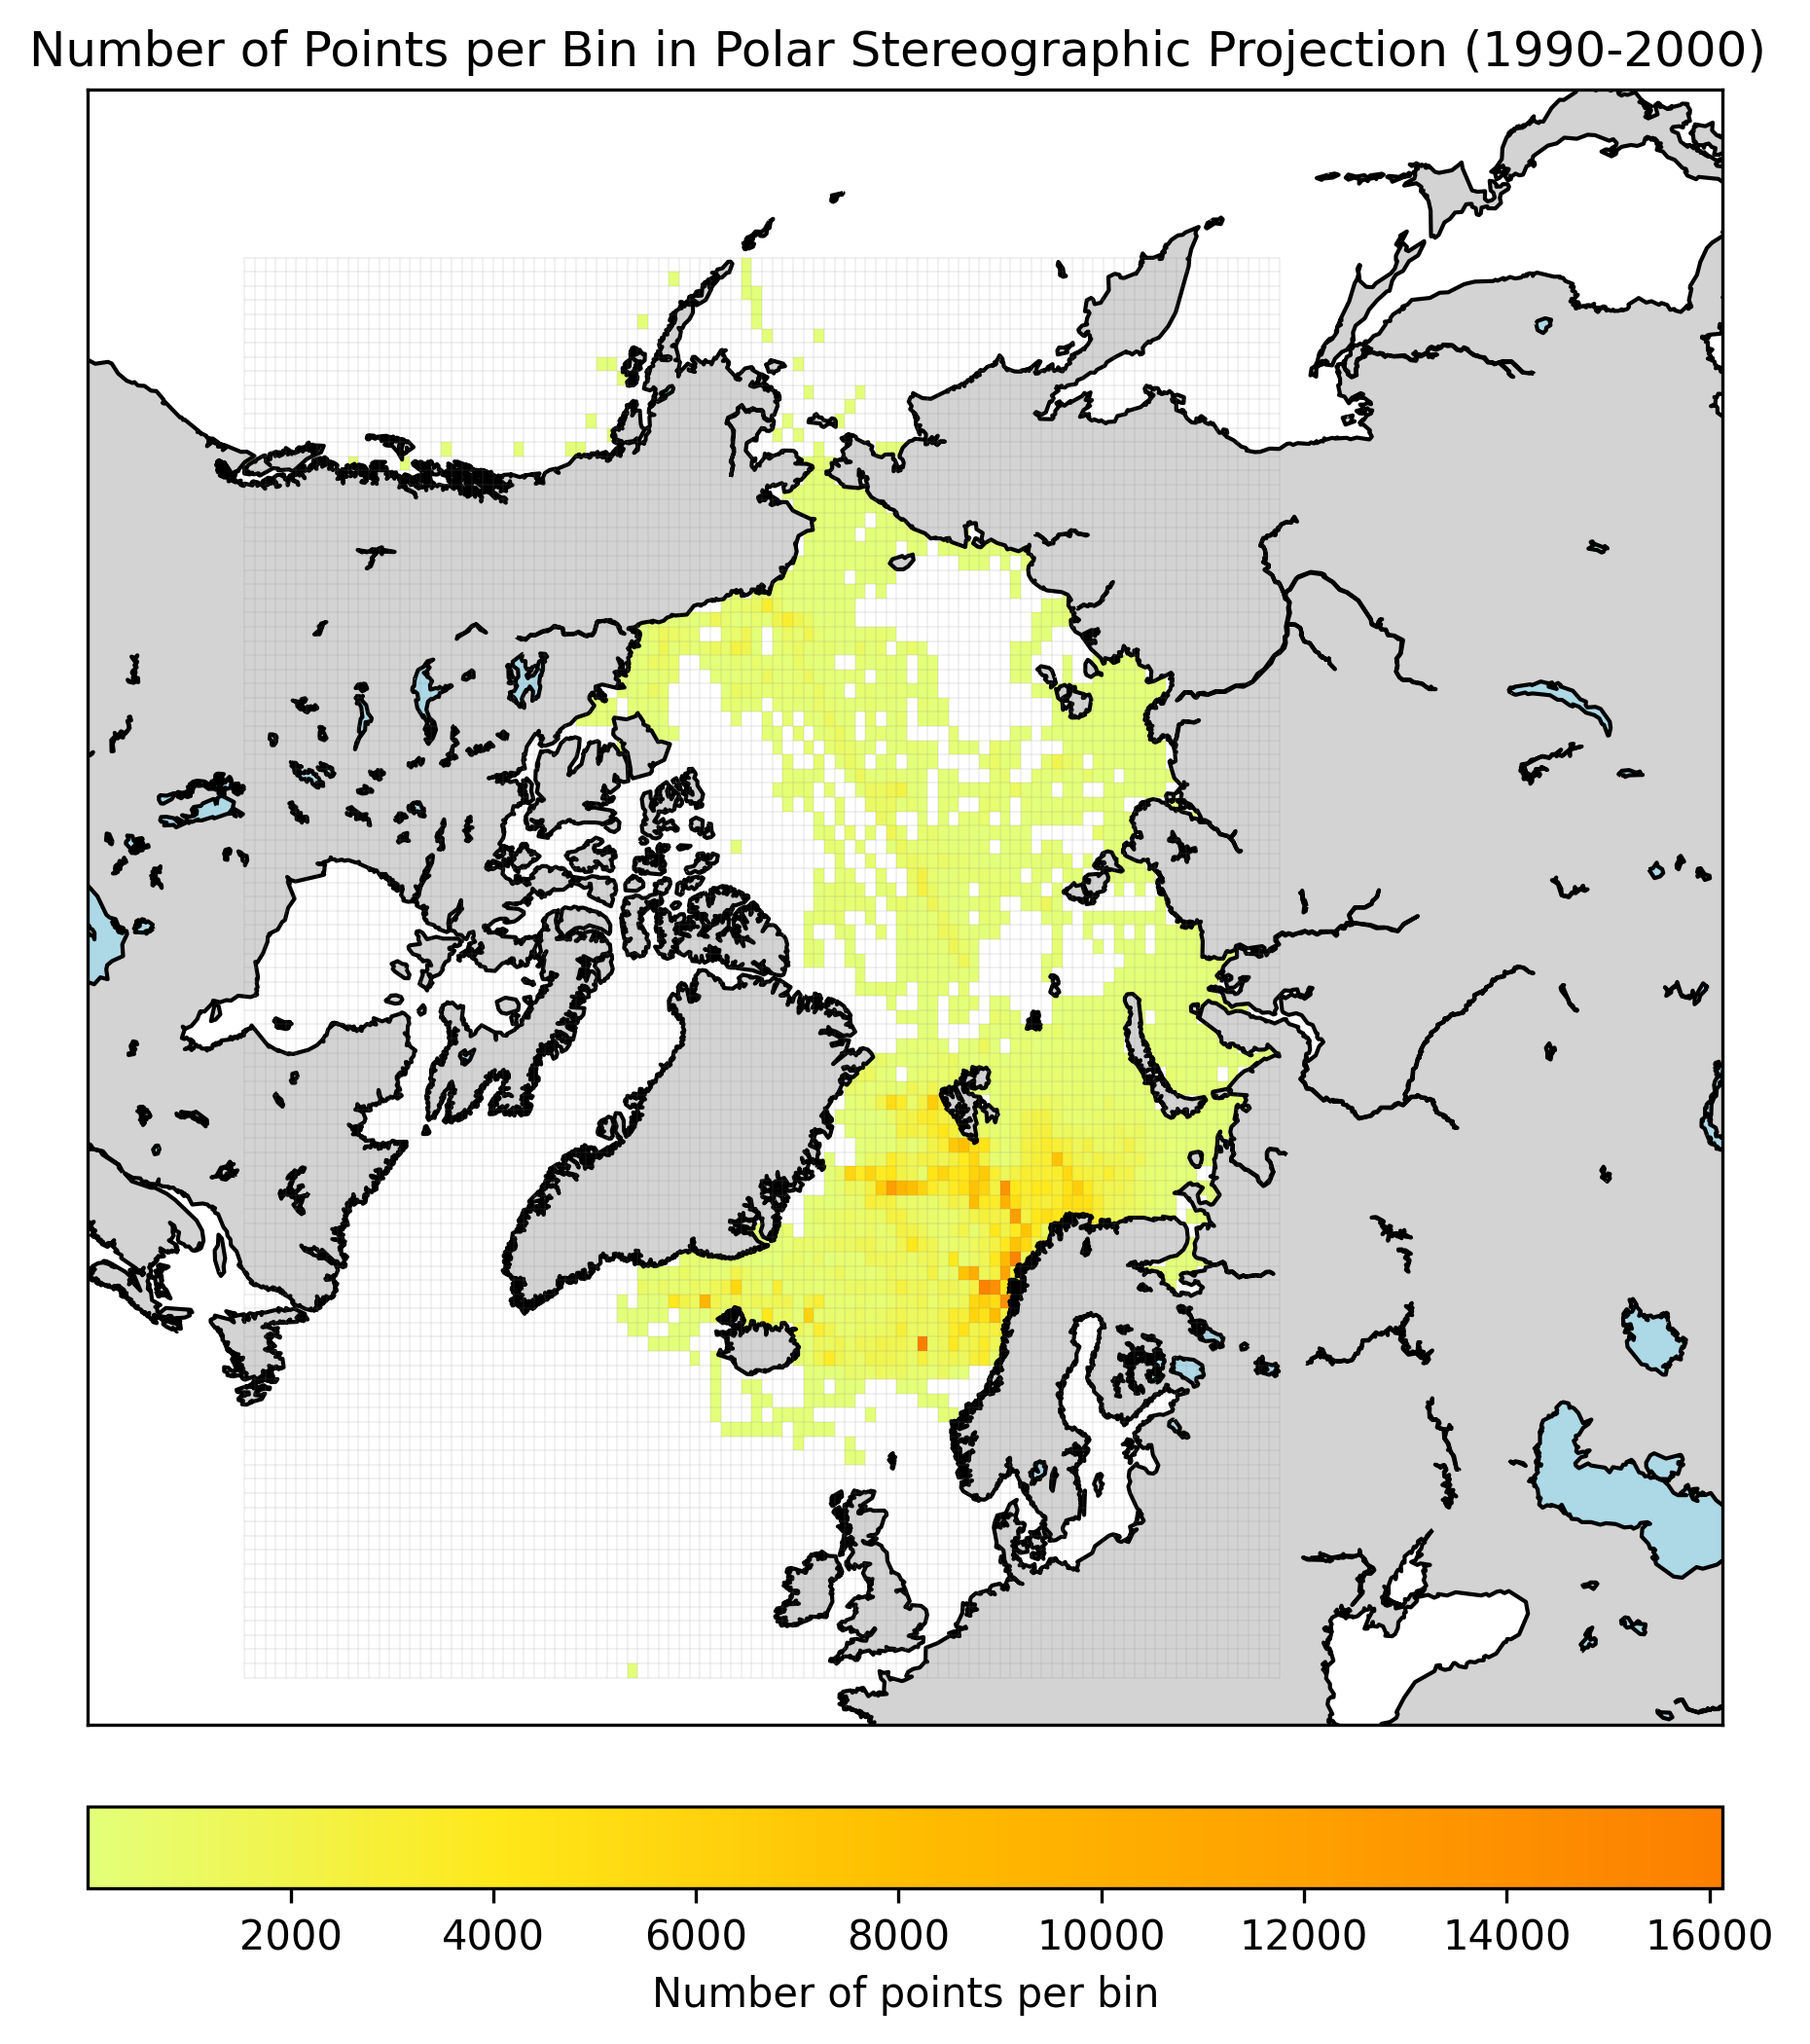

In [11]:
plot_heatmap_npts_xy(df_ST_90_00, n_x_bins=100, n_y_bins=100, projection='npstere', projection_name='Polar Stereographic Projection (1990-2000)')

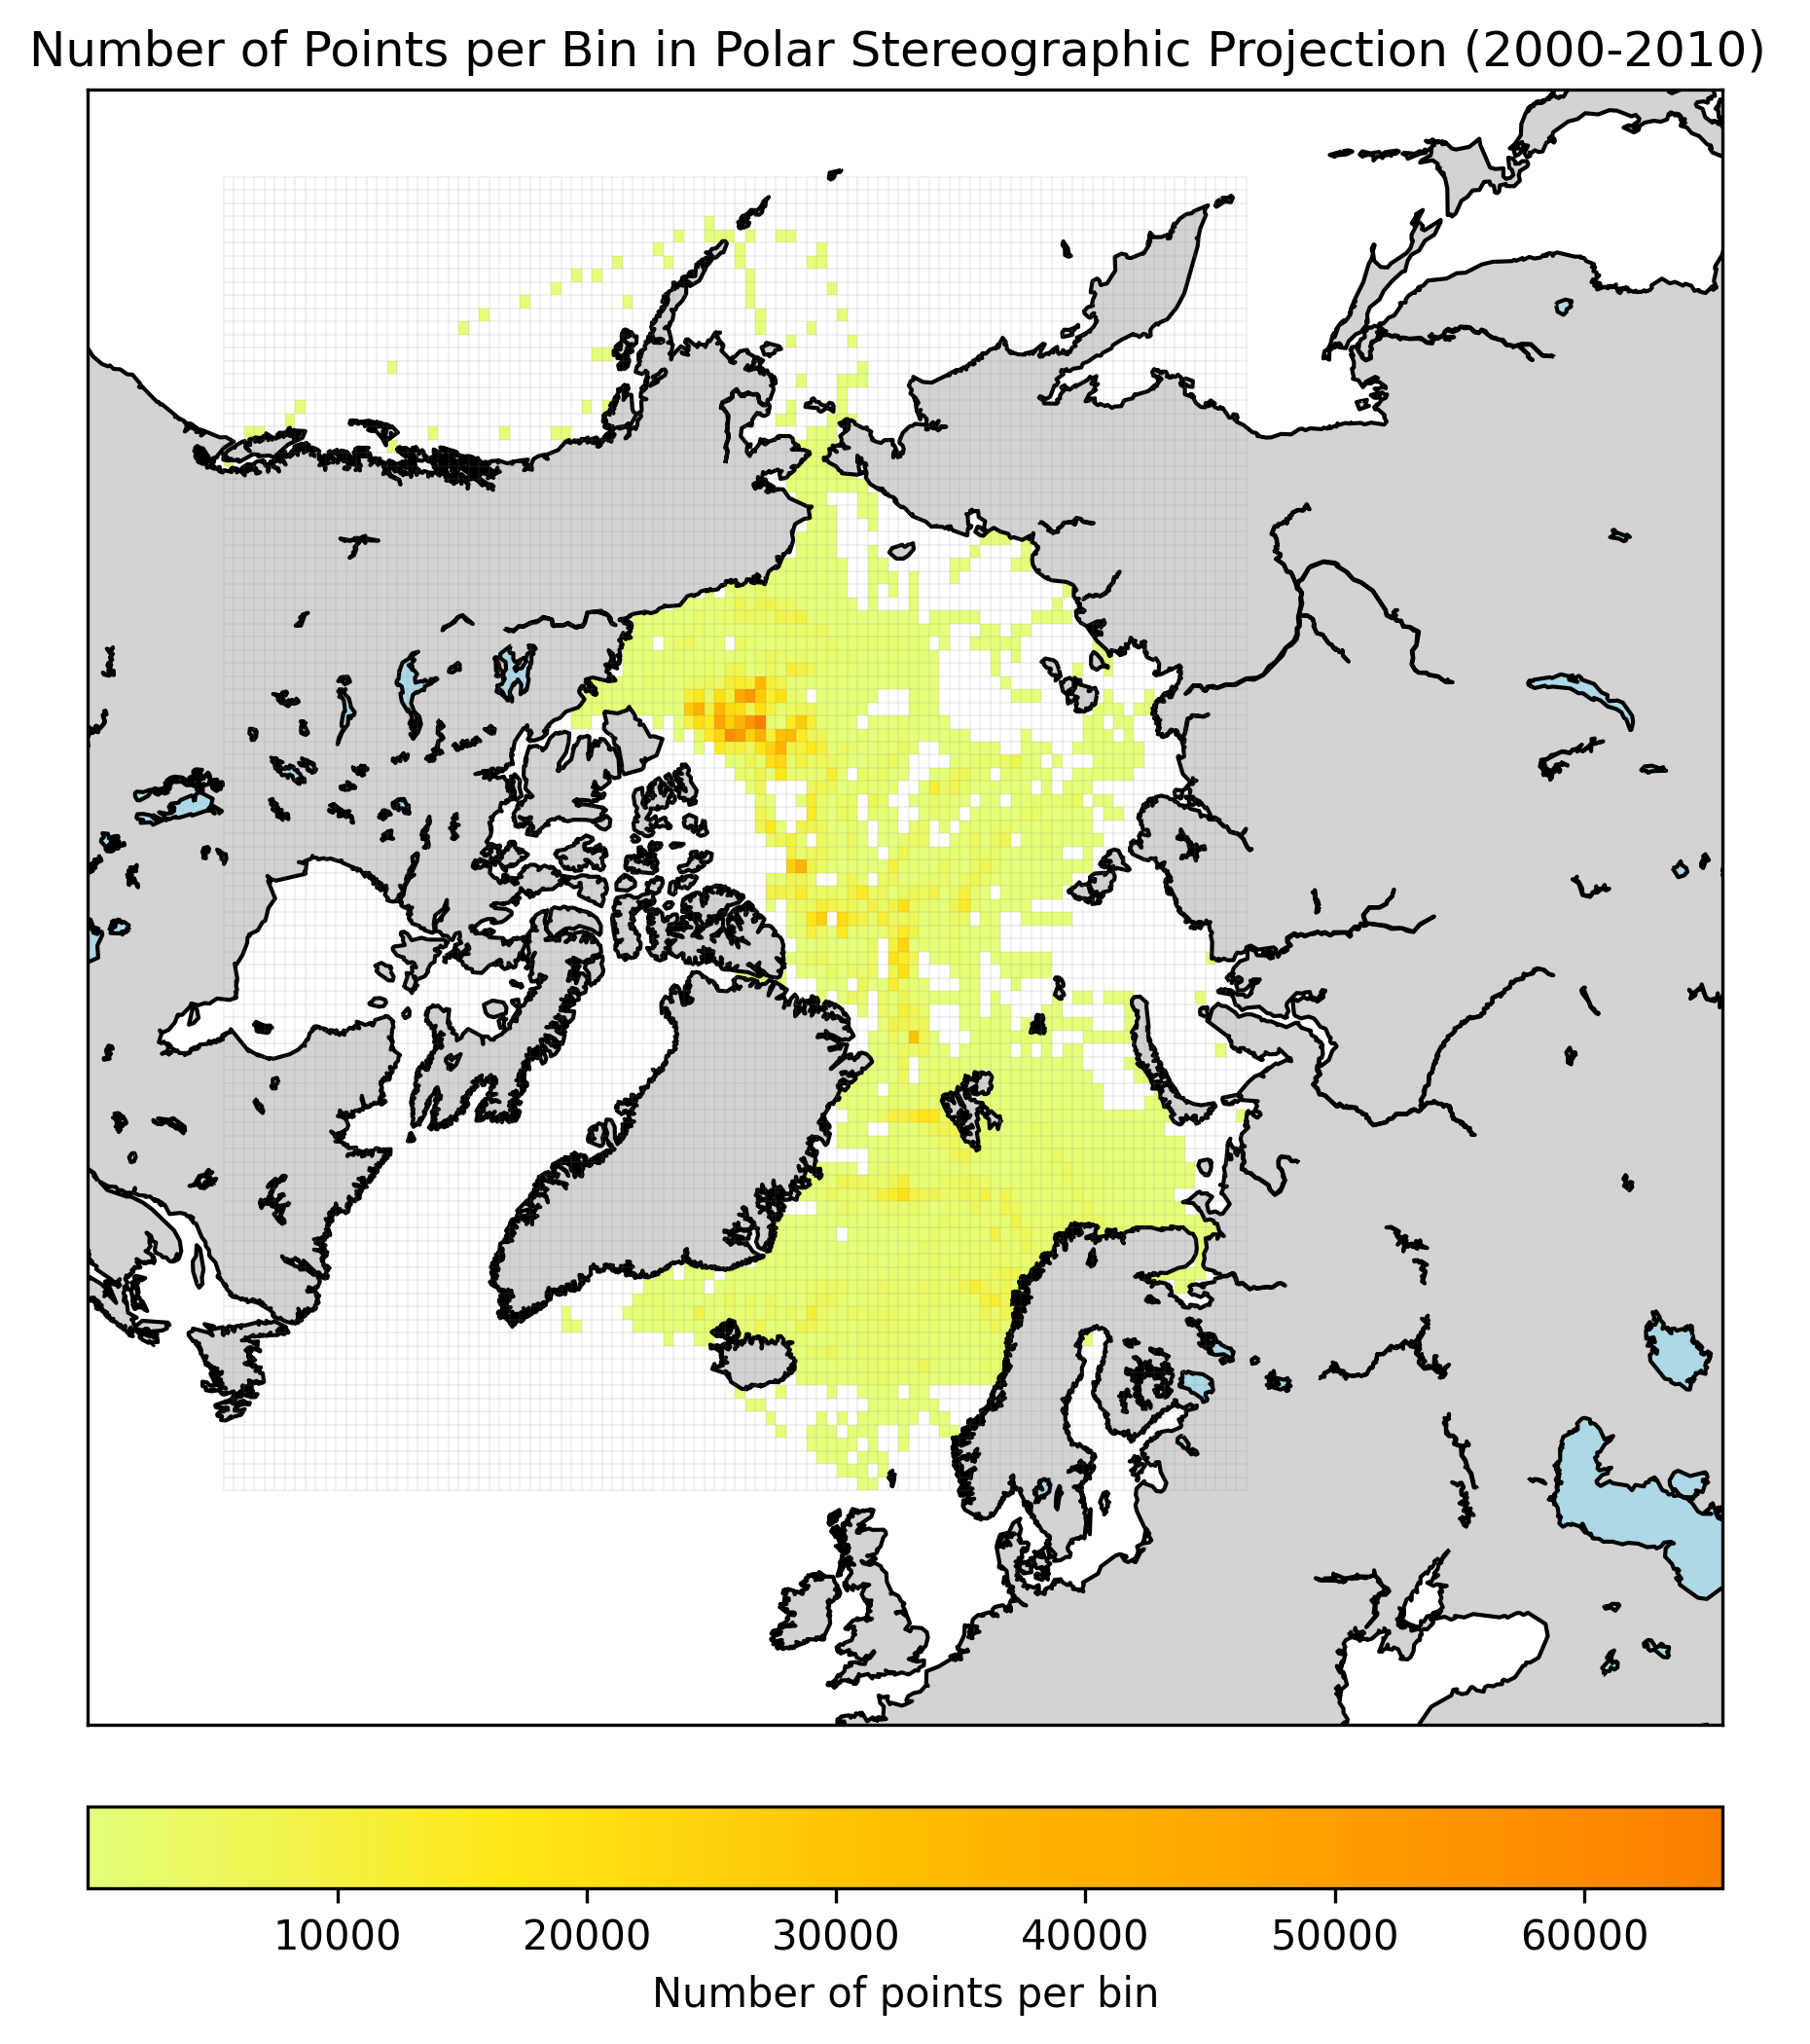

In [12]:
plot_heatmap_npts_xy(df_ST_00_10, n_x_bins=100, n_y_bins=100, projection='npstere', projection_name='Polar Stereographic Projection (2000-2010)')

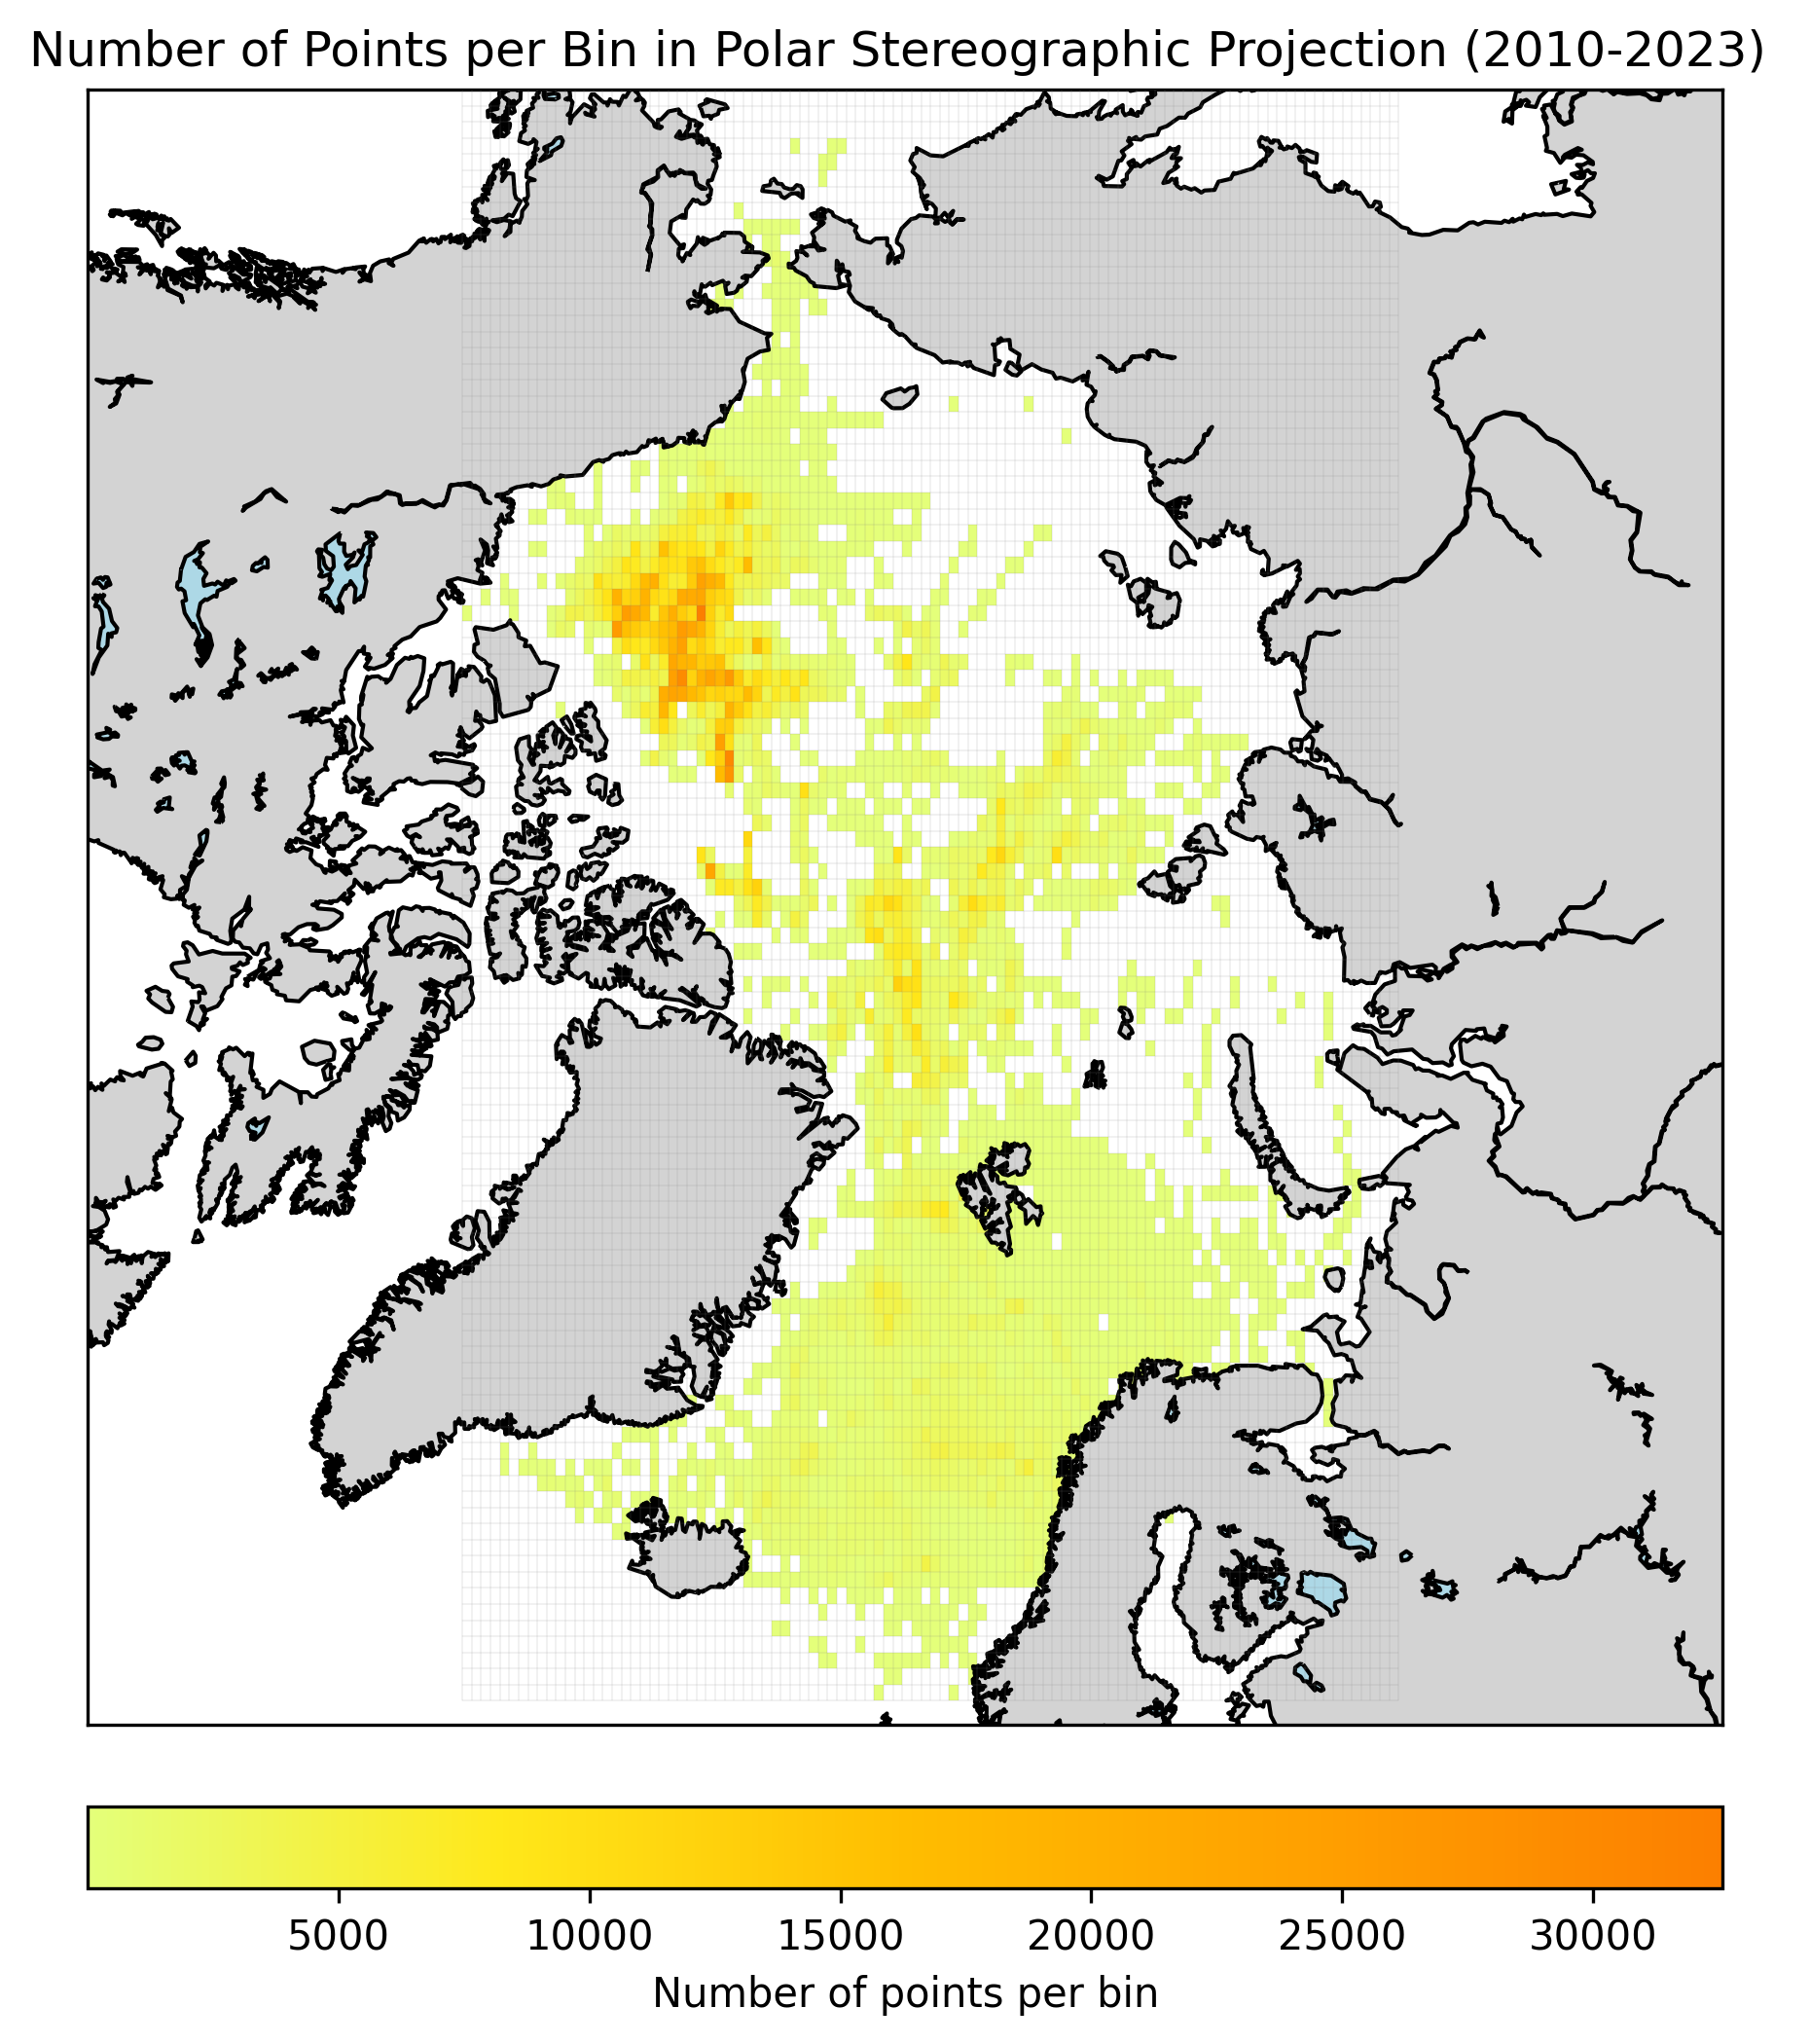

In [13]:
plot_heatmap_npts_xy(df_ST_10_23, n_x_bins=100, n_y_bins=100, projection='npstere', projection_name='Polar Stereographic Projection (2010-2023)')